In [1]:
import pickle
import pandas as pd
import operator
from numba import njit

In [2]:
ot = pd.read_pickle("pickles/sept.pickle")
nt = pd.read_pickle("pickles/tisch.pickle")
bible = pd.concat([ot, nt], axis=0)
strongs = pd.read_pickle("pickles/strongs.pickle")

In [3]:
with open('references-naive.pickle', 'rb') as f:
    found = pickle.load(f)

found = sorted(found, key=operator.itemgetter(0))

# quote start, quote end, source start, source end
found = [((nloc, nloc+nlen), (oloc, oloc+olen)) for nloc, nlen, oloc, olen in found]

In [4]:
@njit
def locs_overlap(loc1, loc2):
    s1, e1 = loc1
    s2, e2 = loc2
    return s1 <= s2 <= e1 or s2 <= s1 <= e2


@njit
def refs_overlap(ref1, ref2):
    nloc1, oloc1 = ref1
    nloc2, oloc2 = ref2
    return locs_overlap(nloc1, nloc2) and locs_overlap(oloc1, oloc2)


@njit
def merge_locs(loc1, loc2):
    s1, e1 = loc1
    s2, e2 = loc2
    return min(s1, s2), max(e1, e2)


@njit
def merge_refs(ref1, ref2):
    nloc1, oloc1 = ref1
    nloc2, oloc2 = ref2
    return merge_locs(nloc1, nloc2), merge_locs(oloc1, oloc2)


@njit
def mergify(found):
    merged = []
    deleted = [False] * len(found)
    for ridx1, ref1 in enumerate(found):
        if deleted[ridx1]: continue
        for ridx2 in range(ridx1+1, len(found)):
            ref2 = found[ridx2]
            if refs_overlap(ref1, ref2):
                if deleted[ridx2]: raise Exception
                merged.append(merge_refs(ref1, ref2))
                deleted[ridx2] = True
    return merged

In [5]:
merged = mergify(found)
len(merged)

1484

In [6]:
merged = mergify(found)
len(merged)

1484

In [7]:
references = pd.DataFrame(columns=['nstart', 'nlen', 'nend', 'ostart', 'olen', 'oend'], dtype=int)
for (nstart, nend), (ostart, oend) in merged:
    references.loc[len(references)] = [nstart, nend-nstart, nend, ostart, oend-ostart, oend]

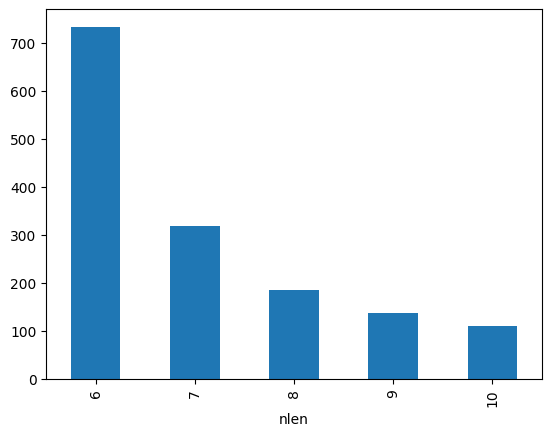

In [8]:
references['nlen'].value_counts().plot.bar();

In [23]:
bible.iloc[references[references.eval('nlen - olen') != 0]['ostart']][['book', 'chapter', 'verse']]

,book,chapter,verse
106185,5,6,5
106186,5,6,5
106188,5,6,5
106189,5,6,5
104782,5,4,29
109429,5,11,13
118288,5,26,16
121317,5,30,2
137037,6,22,5
137039,6,22,5


In [24]:
bible.iloc[references[references.eval('nlen - olen') != 0]['nstart']][['book', 'chapter', 'verse']]

,book,chapter,verse
26436,41,12,30
26436,41,12,30
26436,41,12,30
26436,41,12,30
26438,41,12,30
26438,41,12,30
26438,41,12,30
26438,41,12,30
26442,41,12,30
26442,41,12,30
